In [32]:
import pandas as pd

df = pd.read_csv("../data/Advertisements-Data.csv")

df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


In [33]:
df.shape

(1000, 10)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.2+ KB


In [35]:
df.isnull().sum()

Daily Time Spent on Site    0
Age                         0
Area Income                 0
Daily Internet Usage        0
Ad Topic Line               0
City                        0
Male                        0
Country                     0
Timestamp                   0
Clicked on Ad               0
dtype: int64

In [36]:
df_model = df.drop(
    ["Ad Topic Line","City","Country","Timestamp"],
    axis=1
)

df_model.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
0,68.95,35,61833.90,256.09,0,0
1,80.23,31,68441.85,193.77,1,0
2,69.47,26,59785.94,236.50,0,0
3,74.15,29,54806.18,245.89,1,0
4,68.37,35,73889.99,225.58,0,0


In [38]:
X = df_model.drop("Clicked on Ad", axis=1)
y = df_model["Clicked on Ad"]

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [40]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [41]:
from sklearn.metrics import roc_auc_score

pred_probs = model.predict_proba(X_test)[:,1]

roc_auc_score(y_test, pred_probs)

0.9810709585990485

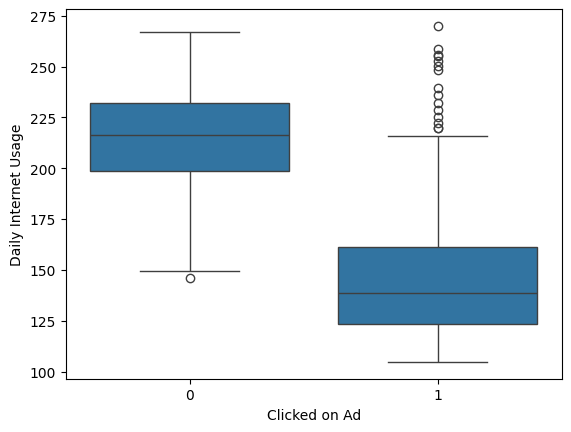

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="Clicked on Ad", y="Daily Internet Usage", data=df)
plt.show()

In [43]:
importance = pd.Series(model.coef_[0], index=X.columns)
importance.sort_values(ascending=False)

Age                         0.175325
Area Income                -0.000151
Daily Internet Usage       -0.073479
Daily Time Spent on Site   -0.192655
Male                       -0.740430
dtype: float64

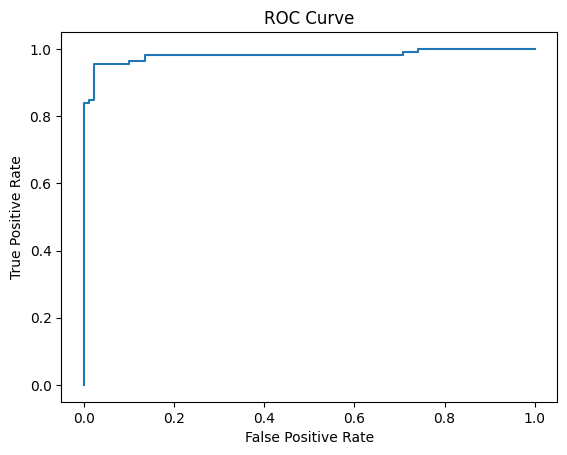

In [44]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, pred_probs)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [47]:
pred_probs = model.predict_proba(X_test)[:,1]

print(pred_probs[:10])

[0.99414232 0.99996363 0.99976432 0.99912723 0.00515578 0.51786406
 0.01198964 0.99997003 0.00510183 0.99999619]


In [48]:
from sklearn.metrics import roc_auc_score

pred_probs = model.predict_proba(X_test)[:,1]

roc_auc_score(y_test, pred_probs)

0.9810709585990485

In [49]:
import pandas as pd

ranking_df = pd.DataFrame({
    "Ad_ID": range(len(pred_probs)),
    "Actual_Click": y_test.values,
    "Predicted_CTR": pred_probs
})

ranking_df.head()

,Ad_ID,Actual_Click,Predicted_CTR
0,0,1,0.994142
1,1,1,0.999964
2,2,1,0.999764
3,3,1,0.999127
4,4,0,0.005156


In [50]:
ranking_df_sorted = ranking_df.sort_values(
    by="Predicted_CTR",
    ascending=False
)

ranking_df_sorted.head(10)

,Ad_ID,Actual_Click,Predicted_CTR
178,178,1,1.000000
16,16,1,1.000000
110,110,1,1.000000
39,39,1,0.999999
50,50,1,0.999999
57,57,1,0.999999
25,25,1,0.999999
156,156,1,0.999999
77,77,1,0.999998
96,96,1,0.999998


In [51]:
top_ads = ranking_df_sorted.head(5)

print(top_ads)

     Ad_ID  Actual_Click  Predicted_CTR
178    178             1       1.000000
16      16             1       1.000000
110    110             1       1.000000
39      39             1       0.999999
50      50             1       0.999999


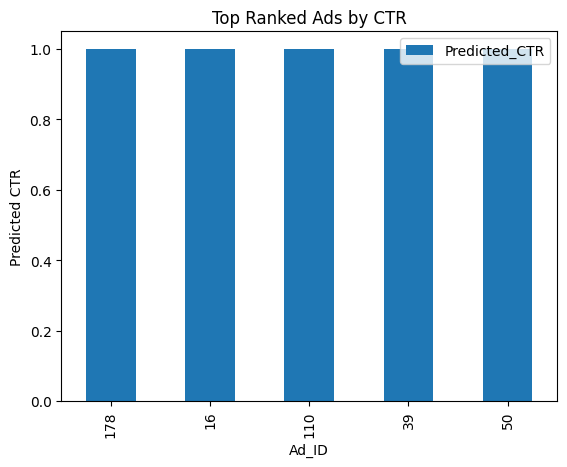

In [52]:
import matplotlib.pyplot as plt

top_ads.plot(
    x="Ad_ID",
    y="Predicted_CTR",
    kind="bar"
)

plt.title("Top Ranked Ads by CTR")
plt.ylabel("Predicted CTR")
plt.show()

In [53]:
import pandas as pd

feature_importance = pd.Series(
    model.coef_[0],
    index=X.columns
)

feature_importance.sort_values(ascending=False)

Age                         0.175325
Area Income                -0.000151
Daily Internet Usage       -0.073479
Daily Time Spent on Site   -0.192655
Male                       -0.740430
dtype: float64

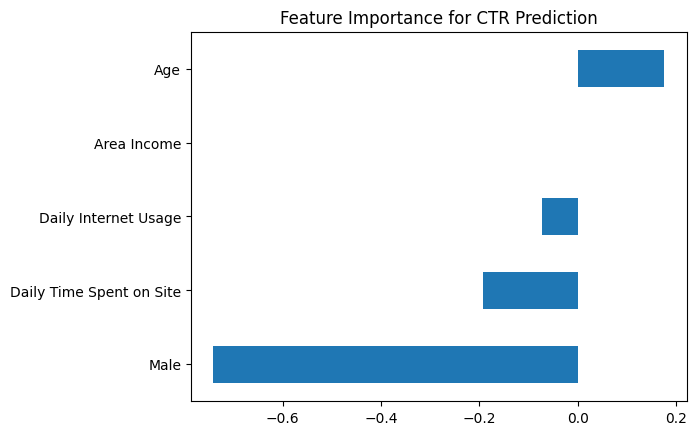

In [54]:
feature_importance.sort_values().plot(kind="barh")
plt.title("Feature Importance for CTR Prediction")
plt.show()

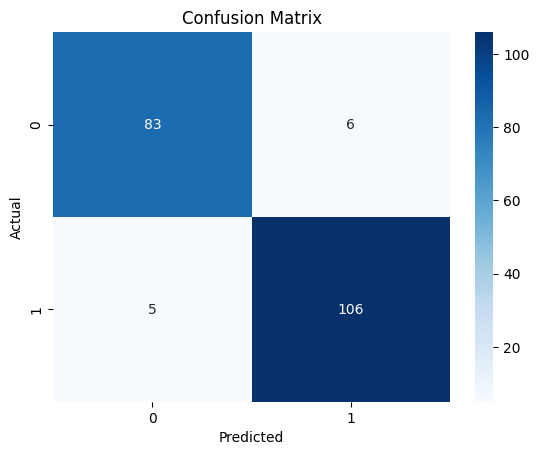

In [55]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

pred_labels = model.predict(X_test)

cm = confusion_matrix(y_test, pred_labels)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [56]:
import joblib

joblib.dump(model, "ctr_prediction_model.pkl")

['ctr_prediction_model.pkl']

In [57]:
model = joblib.load("ctr_prediction_model.pkl")

In [58]:
!pip install xgboost

You should consider upgrading via the 'E:\adclickprediction\venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [59]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [60]:
xgb_probs = xgb_model.predict_proba(X_test)[:,1]

print(xgb_probs[:10])

[0.99680954 0.9989827  0.9990841  0.99666035 0.00513051 0.62379104
 0.01776011 0.9993511  0.00471401 0.99932086]


In [61]:
from sklearn.metrics import roc_auc_score

xgb_auc = roc_auc_score(y_test, xgb_probs)

print("XGBoost AUC:", xgb_auc)

XGBoost AUC: 0.9832979046462194


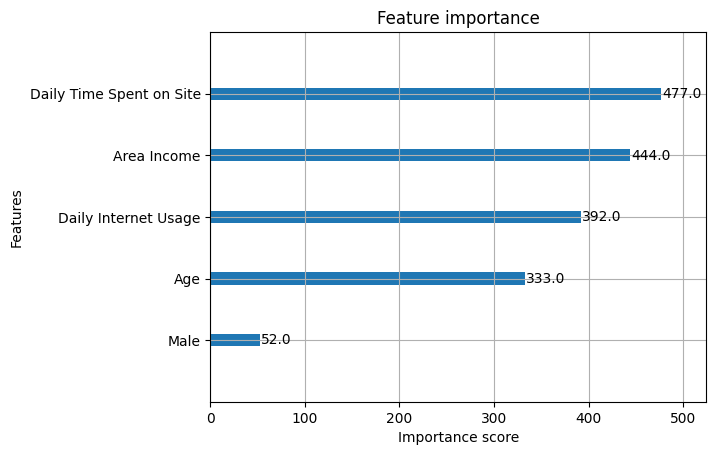

In [62]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(xgb_model)
plt.show()

In [63]:
ranking_df["Predicted_CTR"] = xgb_probs

ranking_df.sort_values(
    by="Predicted_CTR",
    ascending=False
).head(10)

,Ad_ID,Actual_Click,Predicted_CTR
197,197,1,0.999473
16,16,1,0.999466
178,178,1,0.999466
25,25,1,0.999450
102,102,1,0.999444
22,22,1,0.999425
156,156,1,0.999423
39,39,1,0.999418
110,110,1,0.999418
80,80,1,0.999415
